In [41]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = tf.Variable(3.0)

with tf.GradientTape() as g:
    y = 2 * x * x

dy_dx = g.gradient(y, x)

W0000 00:00:1782569444.786841  200362 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
print(dy_dx)

tf.Tensor(12.0, shape=(), dtype=float32)


In [4]:
x1 = tf.Variable(4.0)
x2 = tf.Variable(3.0)

with tf.GradientTape() as g:
    y = x1 + 2 * x2

dy_dx1, dy_dx2 = g.gradient(y, [x1, x2])

print(dy_dx1)
print(dy_dx2)

tf.Tensor(1.0, shape=(), dtype=float32)
tf.Tensor(2.0, shape=(), dtype=float32)


In [5]:
x = tf.constant(3.0)

with tf.GradientTape() as g:
    y = 2 * x * x

dy_dx = g.gradient(y, x)

print(dy_dx)

None


In [6]:
x = tf.constant(3.0)

with tf.GradientTape() as g:
    g.watch(x)
    y = 2 * x * x

dy_dx = g.gradient(y, x)

print(dy_dx)

tf.Tensor(12.0, shape=(), dtype=float32)


___

In [7]:
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import Adam

In [8]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
y_train.shape

(60000,)

In [11]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

In [12]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [13]:
model  = Sequential(
    [
        Input(shape=(28*28, )),
        Dense(128, activation='relu'),
        Dense(10, activation='relu'),
        Dense(10)
    ]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,880 (397.97 KB)

 Trainable params: 101,880 (397.97 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [16]:
def loss(model, x, y, training):
    y_ = model(x, training=training)

    return loss_obj(y, y_pred=y_)

In [17]:
l = loss(model, x_train, y_train, training=False)
print(f"Loss Before Training is: {l}")

Loss Before Training is: 162.08016967773438


In [18]:
for weight in model.trainable_variables:
    print(weight.shape)

(784, 128)
(128,)
(128, 10)
(10,)
(10, 10)
(10,)


In [19]:
def grad(model, input, output):
    with tf.GradientTape() as g:
        loss_valu = loss(model, x_train, y_train, training=True)

    return loss_valu, g.gradient(loss_valu, model.trainable_variables)

In [20]:
loss_valu, gradients = grad(model, x_train, y_train)

In [21]:
loss_valu

<tf.Tensor: shape=(), dtype=float32, numpy=162.08016967773438>

In [22]:
for weight in gradients:
    print(weight.shape)

(784, 128)
(128,)
(128, 10)
(10,)
(10, 10)
(10,)


In [23]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001)

In [24]:
optimizer.iterations.numpy()

np.int64(0)

In [25]:
optimizer.apply_gradients(zip(gradients, model.trainable_variables))

<Variable path=SGD/iteration, shape=(), dtype=int64, value=1>

In [26]:
loss_valu

<tf.Tensor: shape=(), dtype=float32, numpy=162.08016967773438>

In [27]:
loss(model, x_train, y_train, training=True)

<tf.Tensor: shape=(), dtype=float32, numpy=94.42052459716797>

In [28]:
optimizer.iterations.numpy()

np.int64(1)

In [29]:
x_train.shape

(60000, 784)

In [98]:
train_loader = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_loader = train_loader.take(1000)
train_loader = train_loader.skip(1000)

train_loader = train_loader.batch(32).cache().prefetch(tf.data.AUTOTUNE)
val_loader = val_loader.batch(32).cache().prefetch(tf.data.AUTOTUNE)

In [31]:
next(iter(train_loader))

W0000 00:00:1782569446.258773  200362 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(<tf.Tensor: shape=(32, 784), dtype=uint8, numpy=
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(32, 784), dtype=uint8)>,
 <tf.Tensor: shape=(32,), dtype=uint8, numpy=
 array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
        4, 8, 4, 3, 0, 2, 4, 4, 5, 3], dtype=uint8)>)

In [ ]:
train_loader = train_loader.skip()

In [ ]:
num_epochs = 20

train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):

    print(f"Epoch {epoch + 1}/{num_epochs}")

    # Training 
    train_batch_losses = []

    for train_images, train_labels in train_loader:

        with tf.GradientTape() as tape:
            train_predictions = model(train_images, training=True)
            train_loss = loss_obj(train_labels, train_predictions)

        gradients = tape.gradient(train_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        train_batch_losses.append(train_loss.numpy())

    train_epoch_loss = np.mean(train_batch_losses)
    train_loss_history.append(train_epoch_loss)

    # Validation 
    val_batch_losses = []

    for val_images, val_labels in val_loader:

        val_predictions = model(val_images, training=False)
        val_loss = loss_obj(val_labels, val_predictions)

        val_batch_losses.append(val_loss.numpy())

    val_epoch_loss = np.mean(val_batch_losses)
    val_loss_history.append(val_epoch_loss)

    print(
        f"Train Loss: {train_epoch_loss:.4f} | "
        f"Validation Loss: {val_epoch_loss:.4f}"
    )

    print("-" * 60)

Epoch number: 1
Training loss for epoch 1: 2.5198
__________________________________________________
Epoch number: 2
Training loss for epoch 2: 2.1034
__________________________________________________
Epoch number: 3
Training loss for epoch 3: 1.9053
__________________________________________________
Epoch number: 4
Training loss for epoch 4: 1.8539
__________________________________________________
Epoch number: 5
Training loss for epoch 5: 1.8293
__________________________________________________
Epoch number: 6
Training loss for epoch 6: 1.8079
__________________________________________________
Epoch number: 7
Training loss for epoch 7: 1.7882
__________________________________________________
Epoch number: 8
Training loss for epoch 8: 1.7687
__________________________________________________
Epoch number: 9
Training loss for epoch 9: 1.7528
__________________________________________________
Epoch number: 10
Training loss for epoch 10: 1.7364
_______________________________________

In [86]:
del model

In [87]:
model  = Sequential(
    [
        Input(shape=(28*28, )),
        Dense(128, activation='relu'),
        Dense(10, activation='relu'),
        Dense(10)
    ]
)

In [88]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001)

In [89]:
num_epochs = 3
base_lr = 1e-4
factor = 1.1
lr = base_lr

iteration = 0

lr_history = []
loss_history = []

for epoch in range(num_epochs):

    for train_data_batch, train_label_batch in train_loader:

        if iteration % 50 == 0:
            optimizer.learning_rate.assign(lr)
            lr *= factor

        with tf.GradientTape() as tape:
            y_pred = model(train_data_batch, training=True)
            loss = loss_obj(train_label_batch, y_pred)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        lr_history.append(optimizer.learning_rate.numpy())
        loss_history.append(loss.numpy())

        iteration += 1

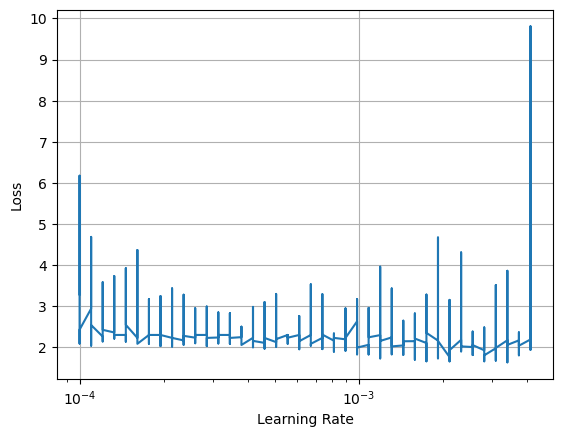

In [96]:
plt.plot(lr_history[10:2000], loss_history[10:2000])
plt.xscale("log")     
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.grid(True)
plt.show()